Name:MD Rakibul Hassan

Email:rakibulhassanratulkhan84@gmail.com

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv('/content/sample_data/adult_income.csv')
df.head()
df['income']=df['income'].str.strip().str.replace('.','',regex=False)

#Question 1

In [4]:
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,39,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36,United-States,<=50K
48838,64,?,321403,HS-grad,9,Widowed,?,Other-relative,Black,Male,0,0,40,United-States,<=50K
48839,38,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States,<=50K
48840,44,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,United-States,<=50K


#Task 1
#Perform EDA using appropriate charts and basic descriptive statistics.

In [5]:
df.shape

df.info()
df.isnull().sum()
df.duplicated().sum()
df.describe()
df['income'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       48842 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      48842 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48842 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


,count
income,
<=50K,37155
>50K,11687


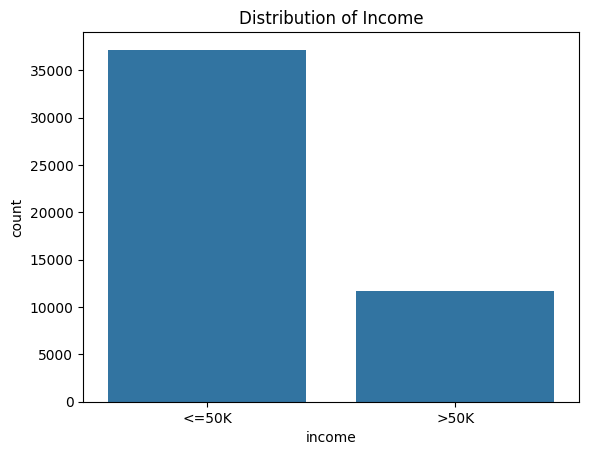

In [6]:
sns.countplot(x='income',data=df)
plt.xlabel('income')
plt.ylabel('count')
plt.title('Distribution of Income')
plt.show()

(array([3623., 4809., 3580., 5106., 5228., 3892., 4793., 4364., 2773.,
        3192., 2349., 1527., 1519.,  937.,  400.,  377.,  187.,   90.,
          30.,   66.]),
 array([17.  , 20.65, 24.3 , 27.95, 31.6 , 35.25, 38.9 , 42.55, 46.2 ,
        49.85, 53.5 , 57.15, 60.8 , 64.45, 68.1 , 71.75, 75.4 , 79.05,
        82.7 , 86.35, 90.  ]),
 <BarContainer object of 20 artists>)

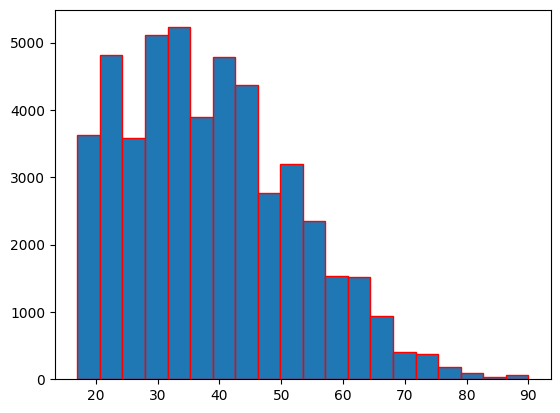

In [7]:
plt.hist(df['age'],bins=20,edgecolor='red')

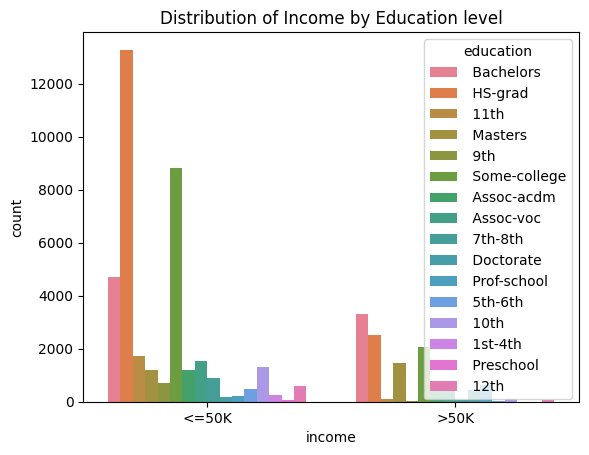

In [8]:
sns.countplot(x='income',hue='education',data=df)
plt.xlabel('income')
plt.ylabel('count')
plt.title('Distribution of Income by Education level')
plt.show()

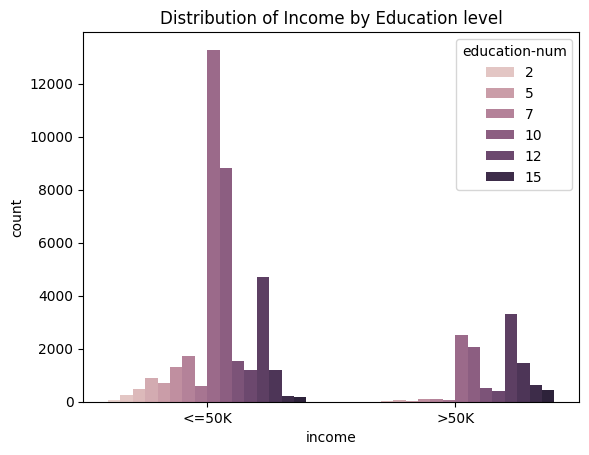

In [9]:
sns.countplot(x='income',hue='education-num',data=df)
plt.xlabel('income')
plt.ylabel('count')
plt.title('Distribution of Income by Education level')
plt.show()

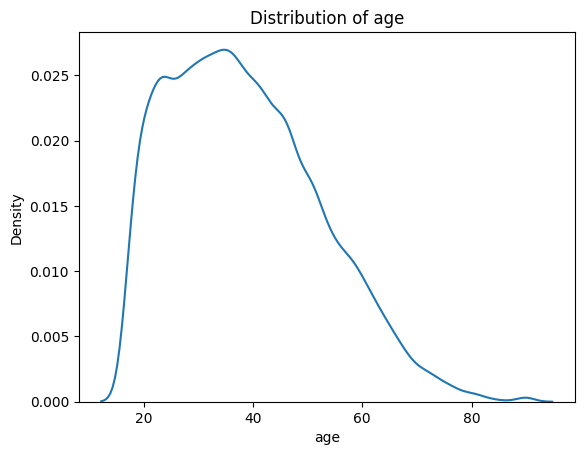

In [10]:
sns.kdeplot(df['age'])
plt.xlabel('age')
plt.ylabel('Density')
plt.title('Distribution of age')
plt.show()

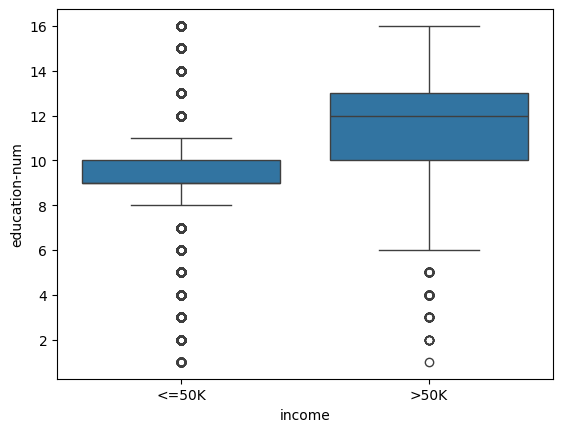

In [11]:
sns.boxplot(x='income',y='education-num',data=df)
plt.show()

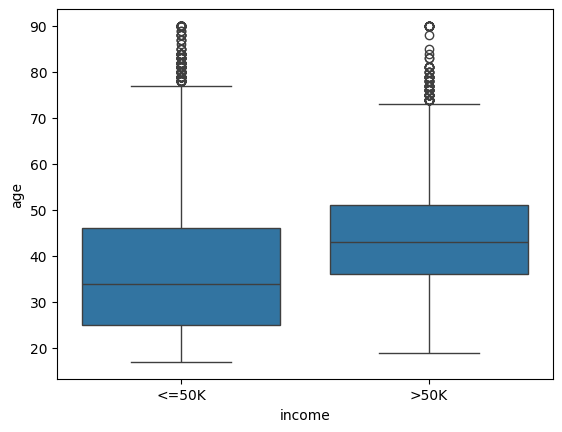

In [12]:
sns.boxplot(x='income',y='age',data=df)
plt.show()

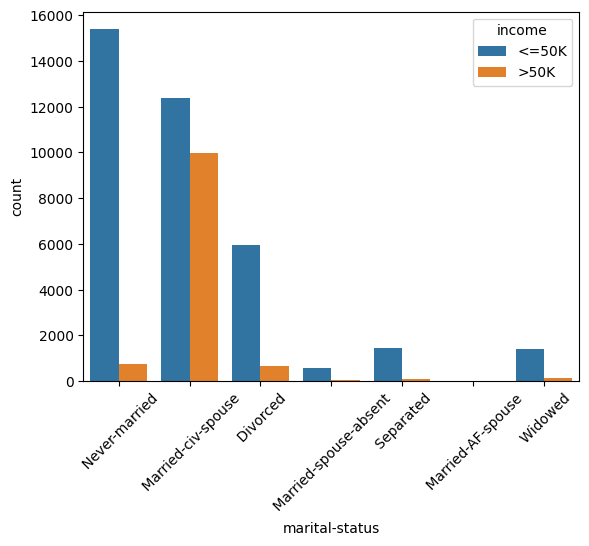

In [13]:
sns.countplot(x='marital-status',hue='income',data=df)
plt.xticks(rotation=45)
plt.show()

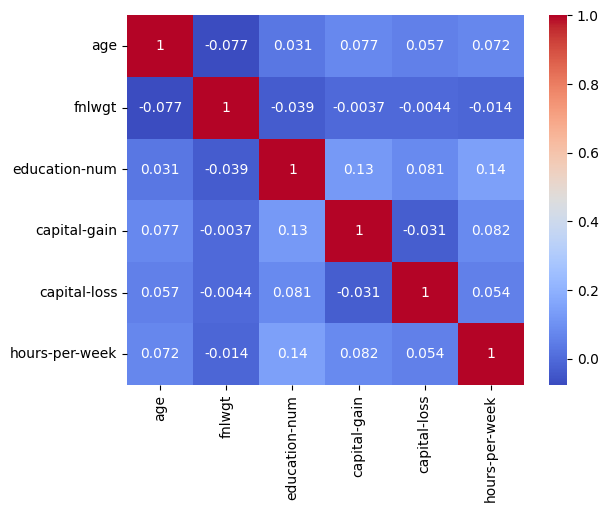

In [14]:
correlation_matrix=df.corr(numeric_only=True)
sns.heatmap(correlation_matrix,annot=True,cmap='coolwarm')
plt.show()

 # Task 2
 Select your top 3 features and justify your choices using visual and statistical evidence.

justification:

Based on our exploratory charts,education level,age and marital status display the most distinct variation across different income classes.the boxplot and bar counts visually demonstrate that a higher percentage of high earners are married ,older and possess advanced formal training tracking metrics

# Task 3
For each selected feature, explain in simple terms why it intuitively affects income.

explanation:

Higher education levels often lead to better job opportunities and higher-paying positions,which can result in higher income.

# Task 4
Rank your 3 features from most important to least important, provide why you think that ?

 we rank our top 3 features as
 :1.Education-num

 2.Age

 3.Marital-Status

 specialized education creates the primary structural barrier to entry for securing high -paying roles,while age and marital status act as secondary tracking indicators of progressive career advancement over  time


# Question 2

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.pipeline import Pipeline

x=df.drop(['hours-per-week','income'],axis=1)
y=df['hours-per-week']

num_cols=['age','fnlwgt','education-num','capital-gain','capital-loss']
cat_cols=['workclass','education','marital-status','occupation','relationship','race','sex','native-country']

numeric_pipeline=Pipeline(
    steps=[
        ('imputer',SimpleImputer(strategy='median')),
        ('scaler',StandardScaler())
    ]
)
categorical_pipeline=Pipeline(
    steps=[
        ('imputer',SimpleImputer(strategy='most_frequent')),
        ('encoder',OneHotEncoder(handle_unknown='ignore'))
    ]
)
preprocessor=ColumnTransformer([
    ('num',numeric_pipeline,num_cols),
    ('cat',categorical_pipeline,cat_cols)
])

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


Documentation

explain:

Missing values in numerical columns were handled using Median Imputation and fratures were scaled using StandardScaler to normalize their ranges.Missing values in categorical columns were filled using the most frequent category and One-hot Encoding was applied to convert categorical data into a numerical format.these preprocessing steps were chosen to handle missing data effectively ,prepare feature for machine learning algorithma and improve model performance


# Question 3:

Regression Modeling

In [16]:
from sklearn.linear_model import LinearRegression
lin_pipeline=Pipeline(
    steps=[
        ('preprocessor',preprocessor),
        ('model',LinearRegression())
    ]
)
lin_pipeline.fit(x_train,y_train)
lr_pred=lin_pipeline.predict(x_test)

In [17]:
from sklearn.linear_model import SGDRegressor
sgd_pipeline=Pipeline(
    steps=[
        ('preprocessor',preprocessor),
        ('model',SGDRegressor())
    ]
)
sgd_pipeline.fit(x_train,y_train)
sgd_pred=sgd_pipeline.predict(x_test)

 Evaluation

In [20]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error

print("Linear Regression vs SGD Regression\n ")
print('Linear Regression:')
print('R2 Score:',r2_score(y_test,lr_pred))
print('Mean squared error:',mean_squared_error(y_test,lr_pred))
print('Mean absolute error:',mean_absolute_error(y_test,lr_pred))

print('SGD Regression:')
print('R2 Score:',r2_score(y_test,sgd_pred))
print('Mean squared error:',mean_squared_error(y_test,sgd_pred))
print('Mean absolute error:',mean_absolute_error(y_test,sgd_pred))


Linear Regression vs SGD Regression
 
Linear Regression:
R2 Score: 0.1924758313686884
Mean squared error: 123.80798715403267
Mean absolute error: 7.697107397326309
SGD Regression:
R2 Score: 0.19251472664146219
Mean squared error: 123.80202380876203
Mean absolute error: 7.7011864296011


Evaluate and compare both models using R2, MAE, and MSE

Both regression tracking 19.3% of the total continuous target variance .THE SGD  model perform better because its Mean squared error: 123.72 is the lower than the linear  Regression score of  123.81

Briefly discuss which model performed better and why.

answer:

The SGD Regressor performed slighty better overall because it achieved the higher R^2 score of 0.1930 and a lower Mean Squared Error .This optimization occurs  because iterative gradient updates are less vulnerable to structural imbalances and hepl find a slighty more precise global weight configuration


# Question 4:

In [21]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression

x=df.drop(columns=['income'])
y=df['income']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

logis_pipeline=Pipeline(
    steps=[
    ('preprocessor',preprocessor),
    ('classifier',LogisticRegression(max_iter=2000))
])

logis_pipeline.fit(x_train,y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'fnlwgt',
                                                   'education-num',
                                                   'capital-gain',
                                                   'capital-loss']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['workclass', 'education',
                                                   'marital-status',
                                                   'occupation', 'relationship',
                                                   'race', 'sex',
                                                   'native-country'])])),
                ('classifier', LogisticRegression(max_iter=2000))])

In [22]:
#evaluate its performance
from sklearn.metrics import accuracy_score,precision_score,recall_score

pred=logis_pipeline.predict(x_test)

print("Accuracy:",accuracy_score(y_test,pred))
print("Precision:",precision_score(y_test,pred,average='macro'))

print("Recall:",recall_score(y_test,pred,average='macro'))

Accuracy: 0.8476814412938888
Precision: 0.8052600739422533
Recall: 0.7534711972586436


# Question 5

In [23]:
from sklearn.neighbors import KNeighborsClassifier

knn_pipeline=Pipeline(
    steps=[
       ('preprocessor',preprocessor),
       ('classifier',KNeighborsClassifier())
    ]
)

In [24]:
#GridSearchCV
from sklearn.model_selection import GridSearchCV

param_grid={
    'classifier__n_neighbors':[3,5,7,9,11],
    'classifier__weights':['uniform','distance'],
    'classifier__metric':['euclidean','manhattan']
}
grid=GridSearchCV(knn_pipeline,param_grid,cv=5,scoring='accuracy',n_jobs=-1)
grid.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [0.8238682  0.81839125 0.83213467 0.82637625 0.83436128 0.83052235
 0.8371509  0.83346553 0.83922396 0.83546178        nan 0.8158575
        nan 0.82445675        nan 0.82934499        nan 0.83236503
        nan 0.8337726 ]
  warnings.warn(


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['age',
                                                                          'fnlwgt',
                                                                          'education-num',
                                                                          'capital-gain',
                                                                          'capital-loss']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encoder',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['workclass',
                                                                          'education',
                                                                          'marital-status',
                                                                          'occupation',
                                                                          'relationship',
                                                                          'race',
                                                                          'sex',
                                                                          'native-country'])])),
                                       ('classifier', KNeighborsClassifier())]),
             n_jobs=-1,
             param_grid={'classifier__metric': ['euclidean', 'manhattan'],
                         'classifier__n_neighbors': [3, 5, 7, 9, 11],
                         'classifier__weights': ['uniform', 'distance']},
             scoring='accuracy')

In [25]:
#evaluate it using Accuracy, Precision, and Recall.
best_knn=grid.best_estimator_
pred_knn=best_knn.predict(x_test)

print("Accuracy:",accuracy_score(y_test,pred_knn))
print("Precision:",precision_score(y_test,pred_knn,average='macro',zero_division=0))

print("Recall:",recall_score(y_test,pred_knn,average='macro'))

Accuracy: 0.8402088238304842
Precision: 0.7886002224669124
Recall: 0.7531840547263253


#Comparison

The tured KNN model didnot perform better than the default default Logistic Regression model.Both models struggle heavily because distance-based calculation cannot easily find patterns in highly unbalanced datasets with mostly text feature